In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('monthly_milk_production.csv')
df.shape

(168, 2)

In [6]:
df.tail()

,Date,Production
163,1975-08,858
164,1975-09,817
165,1975-10,827
166,1975-11,797
167,1975-12,843


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Date        168 non-null    object
 1   Production  168 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.8+ KB


In [8]:
df.describe()

,Production
count,168.000000
mean,754.708333
std,102.204524
min,553.000000
25%,677.750000
50%,761.000000
75%,824.500000
max,969.000000


In [10]:
df.isnull().sum()

Date          0
Production    0
dtype: int64

In [11]:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

df.head()

,Production
Date,
1962-01-01,589
1962-02-01,561
1962-03-01,640
1962-04-01,656
1962-05-01,727


The date column was converted to datetime format and set as the index for time series analysis.

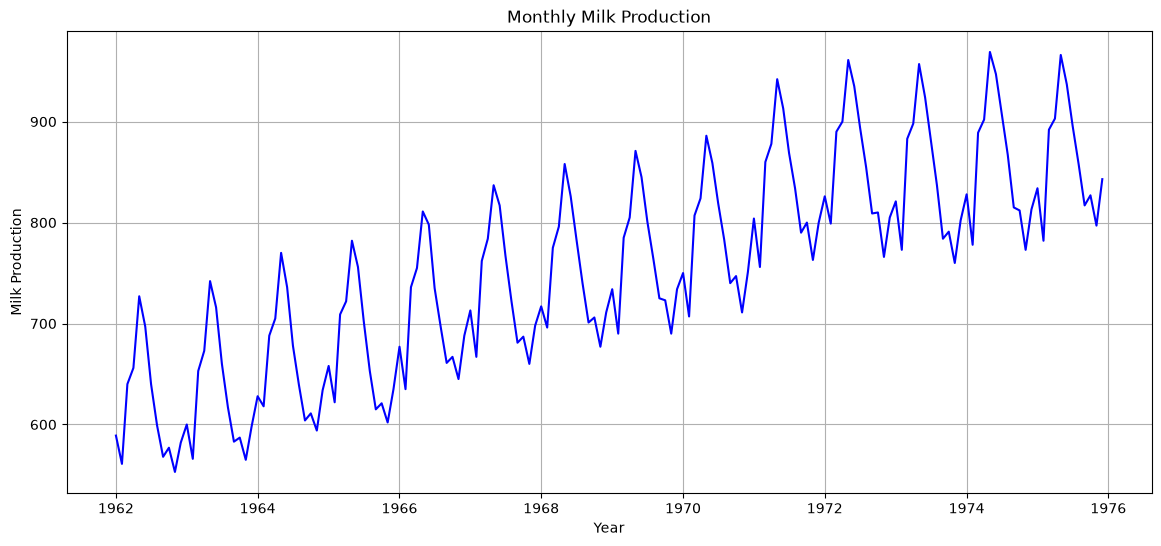

In [13]:
plt.figure(figsize=(14,6))
plt.plot(df.index, df['Production'], color='blue')
plt.title("Monthly Milk Production")
plt.xlabel("Year")
plt.ylabel("Milk Production")
plt.grid(True)
plt.show()

The time series shows an overall increasing trend in milk production over time

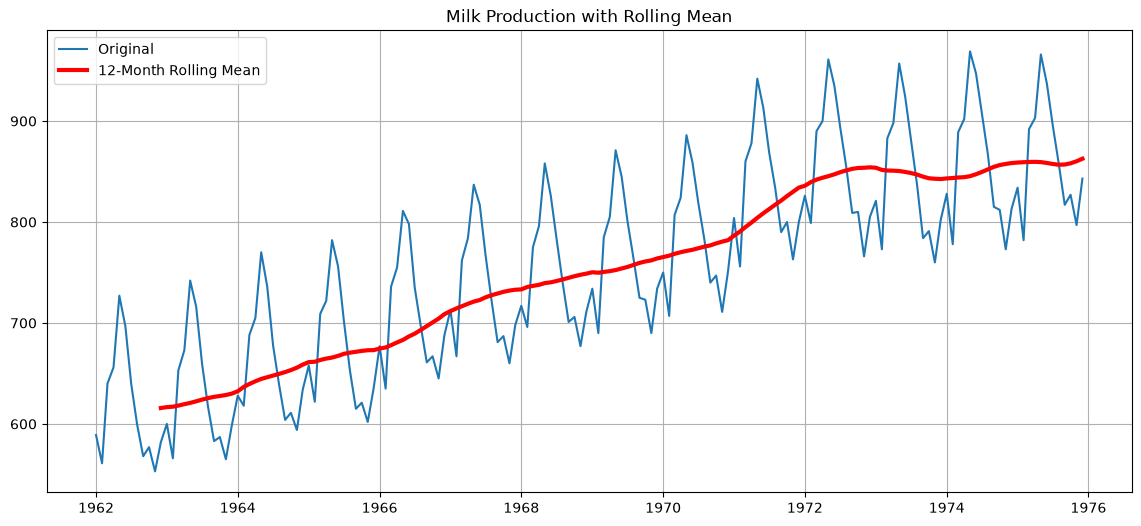

In [14]:
rolling_mean = df['Production'].rolling(window=12).mean()

plt.figure(figsize=(14,6))
plt.plot(df['Production'], label='Original')
plt.plot(rolling_mean, color='red', linewidth=3, label='12-Month Rolling Mean')
plt.title("Milk Production with Rolling Mean")
plt.legend()
plt.grid(True)
plt.show()

- A rolling mean confirms the long-term growth while smoothing short-term fluctuations
- Production tends to rise and fall during similar months each year, indicating strong seasonality

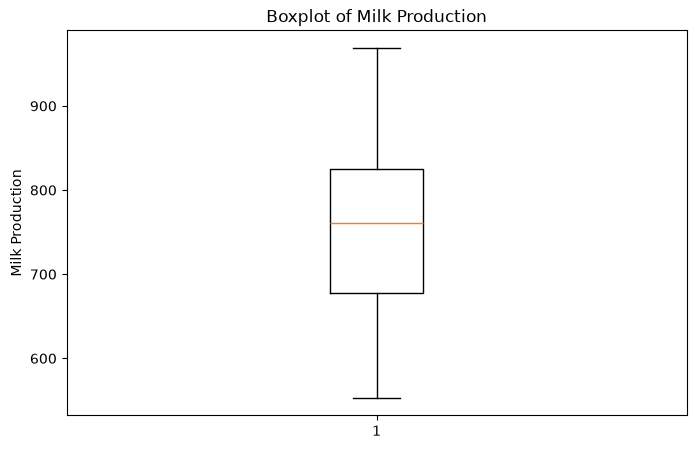

In [15]:
plt.figure(figsize=(8,5))
plt.boxplot(df['Production'])
plt.title("Boxplot of Milk Production")
plt.ylabel("Milk Production")
plt.show()

- there are no out liers, there are no missimg values 

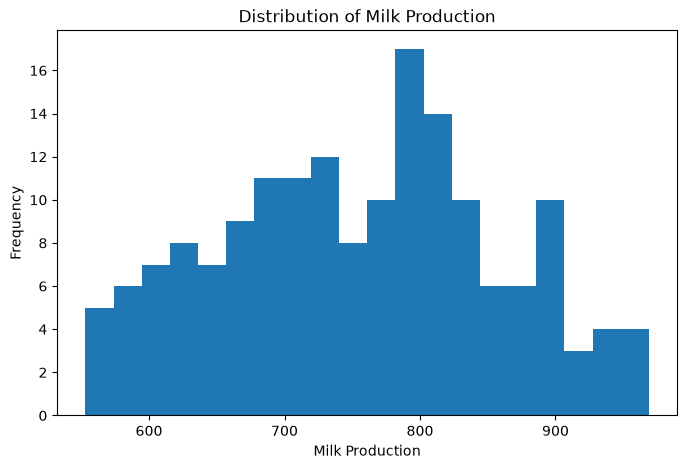

In [17]:
plt.figure(figsize=(8,5))
plt.hist(df['Production'], bins=20)
plt.title("Distribution of Milk Production")
plt.xlabel("Milk Production")
plt.ylabel("Frequency")
plt.show()

The histogram indicates that milk production values are reasonably distributed without severe skewness

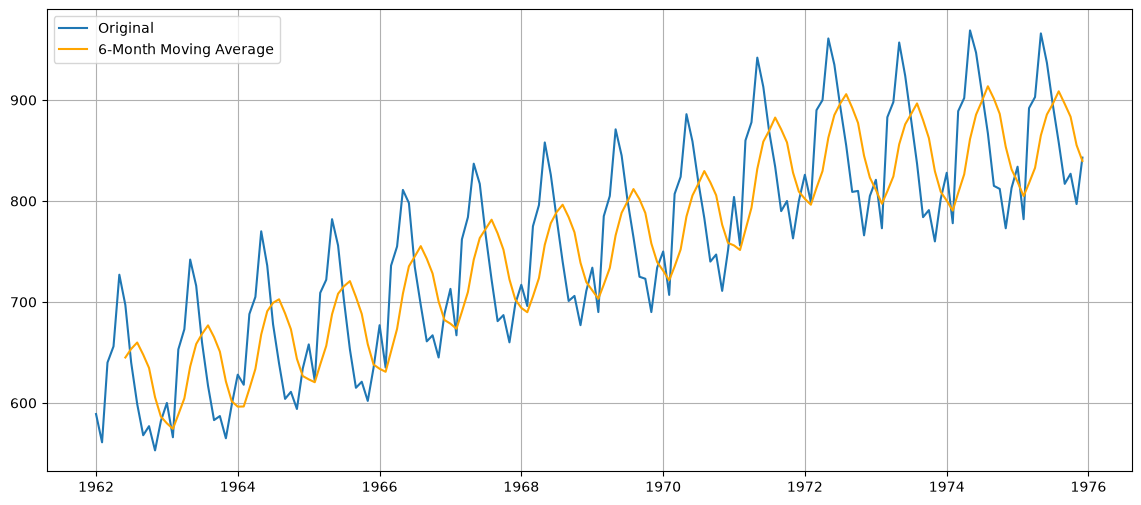

In [19]:
plt.figure(figsize=(14,6))
plt.plot(df['Production'], label='Original')
plt.plot(df['Production'].rolling(6).mean(),
         color='orange',
         label='6-Month Moving Average')

plt.legend()
plt.grid(True)
plt.show()

normalizing the data

In [20]:
from sklearn.preprocessing import MinMaxScaler

In [21]:
scaler = MinMaxScaler(feature_range=(0,1))

scaled_data = scaler.fit_transform(df[['Production']])

scaled_df = pd.DataFrame(
    scaled_data,
    index=df.index,
    columns=['Milk Production']
)

scaled_df.head()

,Milk Production
Date,
1962-01-01,0.086538
1962-02-01,0.019231
1962-03-01,0.209135
1962-04-01,0.247596
1962-05-01,0.418269


Since neural network models are sensitive to the scale of input features, the milk production values were normalized to the range [0, 1] using MinMaxScaler

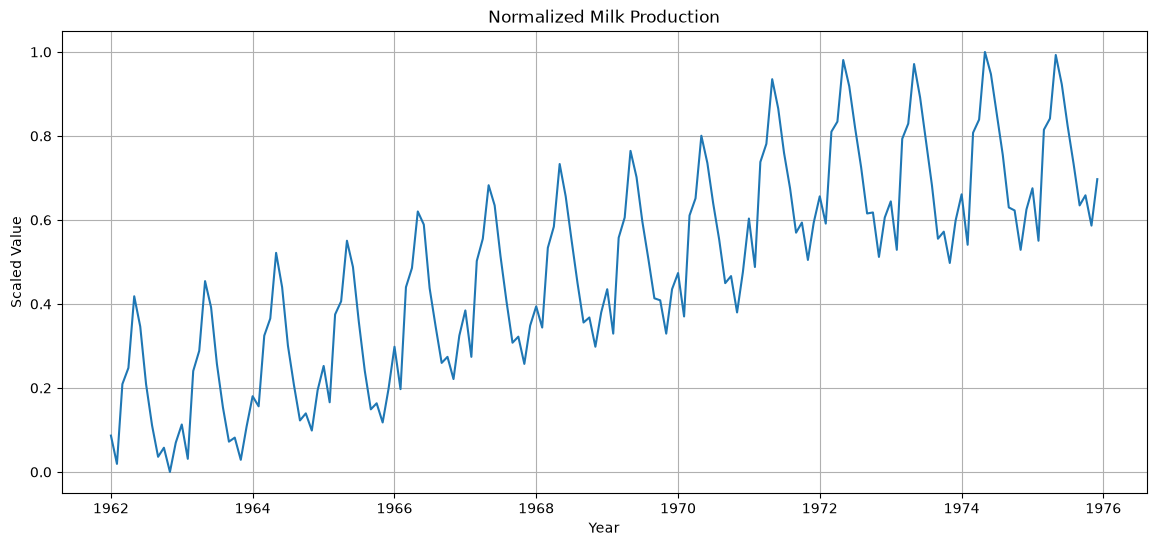

In [22]:
plt.figure(figsize=(14,6))
plt.plot(scaled_df)
plt.title("Normalized Milk Production")
plt.xlabel("Year")
plt.ylabel("Scaled Value")
plt.grid(True)
plt.show()

In [24]:
time_step = 12

def create_sequences(data, time_step):
    x, y = [], []

    for i in range(len(data) - time_step):
        x.append(data[i:i + time_step, 0])
        y.append(data[i + time_step, 0])

    return np.array(x), np.array(y)

x, y = create_sequences(scaled_data, time_step)

In [25]:
x.shape,  y.shape

((156, 12), (156,))

In [27]:
train_size = int(len(x) * 0.70)
val_size = int(len(x) * 0.15)

x_train = x[:train_size]
y_train = y[:train_size]

x_val = x[train_size:train_size + val_size]
y_val = y[train_size:train_size + val_size]

x_test = x[train_size + val_size:]
y_test = y[train_size + val_size:]

print("Training Set :", x_train.shape)
print("Validation Set:", x_val.shape)
print("Testing Set :", x_test.shape)

Training Set : (109, 12)
Validation Set: (23, 12)
Testing Set : (24, 12)


Reshape Data for RNN/LSTM/GRU

In [28]:
x_train = x_train.reshape((x_train.shape[0], x_train.shape[1], 1))
x_val = x_val.reshape((x_val.shape[0], x_val.shape[1], 1))
x_test = x_test.reshape((x_test.shape[0], x_test.shape[1], 1))

- Input Sequences: A sliding window of the previous 12 months is used to predict the next month's milk production.
- Data Split: The dataset is divided into 70% training, 15% validation, and 15% testing to ensure reliable model evaluation and to prevent overfitting.
- Reshaping: The input data is reshaped into the format (samples, time_steps, features), which is required by recurrent neural network architectures such as Simple RNN, LSTM, and GRU.
- Feature Dimension: Since the dataset contains only one feature (monthly milk production), the feature dimension is 1.

#### Model Building

In [29]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [30]:
window_size = 12
rnn_units = 64
lstm_units = 64
gru_units = 64

batch_size = 16
epochs = 100

learning_rate = 0.001

- Window Size = 12: Captures one full year of monthly seasonality.
- 64 Hidden Units: Provides enough model capacity without excessive complexity.
- Batch Size = 16: Balances convergence speed and stable gradient updates.
- Learning Rate = 0.001: A commonly effective value for the Adam optimizer.
- 100 Epochs with Early Stopping: Allows sufficient training while stopping automatically when validation loss no longer improves.

In [31]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

Basic RNN Model

In [32]:
rnn_model = Sequential([
    SimpleRNN(rnn_units, activation='tanh',
              input_shape=(window_size,1)),
    Dense(1)
])

rnn_model.summary()

C:\Users\Basavaraj M\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,289 (16.75 KB)

 Trainable params: 4,289 (16.75 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
rnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=learning_rate
    ),
    loss='mse',
    metrics=['mae']
)

In [34]:
history_rnn = rnn_model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 0.0722 - mae: 0.2222 - val_loss: 0.0050 - val_mae: 0.0598
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0151 - mae: 0.0940 - val_loss: 0.0360 - val_mae: 0.1762
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0082 - mae: 0.0718 - val_loss: 0.0068 - val_mae: 0.0640
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0057 - mae: 0.0632 - val_loss: 0.0094 - val_mae: 0.0816
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0044 - mae: 0.0528 - val_loss: 0.0074 - val_mae: 0.0712
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0031 - mae: 0.0433 - val_loss: 0.0044 - val_mae: 0.0541
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0025 - mae: 0.0400 - val_loss: 0.0043 - val_mae: 0.0547
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0025 - mae: 0.0382 - val_loss: 0.0034 - val_mae: 0.0483
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0021 - mae: 

LSTM Model

In [35]:
lstm_model = Sequential([
    LSTM(lstm_units,
         activation='tanh',
         input_shape=(window_size,1)),
    Dense(1)
])

lstm_model.summary()

C:\Users\Basavaraj M\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=learning_rate
    ),
    loss='mse',
    metrics=['mae']
)

In [38]:
history_lstm = lstm_model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.0823 - mae: 0.2361 - val_loss: 0.0406 - val_mae: 0.1532
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0274 - mae: 0.1436 - val_loss: 0.0436 - val_mae: 0.1736
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0293 - mae: 0.1510 - val_loss: 0.0305 - val_mae: 0.1437
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0250 - mae: 0.1314 - val_loss: 0.0351 - val_mae: 0.1464
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0249 - mae: 0.1335 - val_loss: 0.0276 - val_mae: 0.1408
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0234 - mae: 0.1332 - val_loss: 0.0257 - val_mae: 0.1405
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0231 - mae: 0.1336 - val_loss: 0.0257 - val_mae: 0.1387
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0226 - mae: 0.1311 - val_loss: 0.0258 - val_mae: 0.1368
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0222 - mae: 

GRU Model

In [39]:
gru_model = Sequential([
    GRU(gru_units,
        activation='tanh',
        input_shape=(window_size,1)),
    Dense(1)
])

gru_model.summary()

C:\Users\Basavaraj M\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,929 (50.50 KB)

 Trainable params: 12,929 (50.50 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
gru_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=learning_rate
    ),
    loss='mse',
    metrics=['mae']
)

In [41]:
history_gru = gru_model.fit(
    x_train,
    y_train,
    validation_data=(x_val,y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step - loss: 0.0996 - mae: 0.2550 - val_loss: 0.0861 - val_mae: 0.2511
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0265 - mae: 0.1331 - val_loss: 0.0255 - val_mae: 0.1427
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0310 - mae: 0.1524 - val_loss: 0.0241 - val_mae: 0.1343
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0239 - mae: 0.1342 - val_loss: 0.0348 - val_mae: 0.1437
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0231 - mae: 0.1262 - val_loss: 0.0406 - val_mae: 0.1548
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0228 - mae: 0.1259 - val_loss: 0.0310 - val_mae: 0.1359
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0213 - mae: 0.1245 - val_loss: 0.0262 - val_mae: 0.1273
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0207 - mae: 0.1234 - val_loss: 0.0265 - val_mae: 0.1272
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0202 - mae: 

Three recurrent neural network architectures were implemented to forecast monthly milk production. A Simple RNN served as the baseline model, while LSTM and GRU were used to better capture long-term temporal dependencies in the time series. All models were trained using the Adam optimizer with a learning rate of 0.001 and Mean Squared Error (MSE) as the loss function. Hyperparameters such as the input window size, number of hidden units, batch size, and epochs were tuned experimentally. A 12-month input window was selected because it effectively captures yearly seasonality, and Early Stopping was applied to prevent overfitting by restoring the best-performing model based on validation loss. These trained models are now ready for performance evaluation and comparison using regression metrics such as RMSE, MAE, and MAPE.

#### Model Evaluation

In [44]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [45]:
rnn_pred = rnn_model.predict(x_test)
lstm_pred = lstm_model.predict(x_test)
gru_pred = gru_model.predict(x_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step


Convert Predictions Back to Original Scale

Since the models were trained on normalized data, convert both predictions and actual values back to the original milk production scale.

In [46]:
rnn_pred = scaler.inverse_transform(rnn_pred)
lstm_pred = scaler.inverse_transform(lstm_pred)
gru_pred = scaler.inverse_transform(gru_pred)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

In [47]:
def evaluate_model(actual, predicted):
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    return rmse, mae, mape

In [48]:
rnn_rmse, rnn_mae, rnn_mape = evaluate_model(y_test_actual, rnn_pred)
lstm_rmse, lstm_mae, lstm_mape = evaluate_model(y_test_actual, lstm_pred)
gru_rmse, gru_mae, gru_mape = evaluate_model(y_test_actual, gru_pred)

In [49]:
results = pd.DataFrame({
    "Model":["Basic RNN","LSTM","GRU"],
    "RMSE":[rnn_rmse,lstm_rmse,gru_rmse],
    "MAE":[rnn_mae,lstm_mae,gru_mae],
    "MAPE (%)":[rnn_mape,lstm_mape,gru_mape]
})

results

,Model,RMSE,MAE,MAPE (%)
0,Basic RNN,15.963947,13.688838,1.567243
1,LSTM,25.758258,20.192169,2.378476
2,GRU,31.164288,24.308385,2.866559


Plot Actual vs Predicted (RNN)

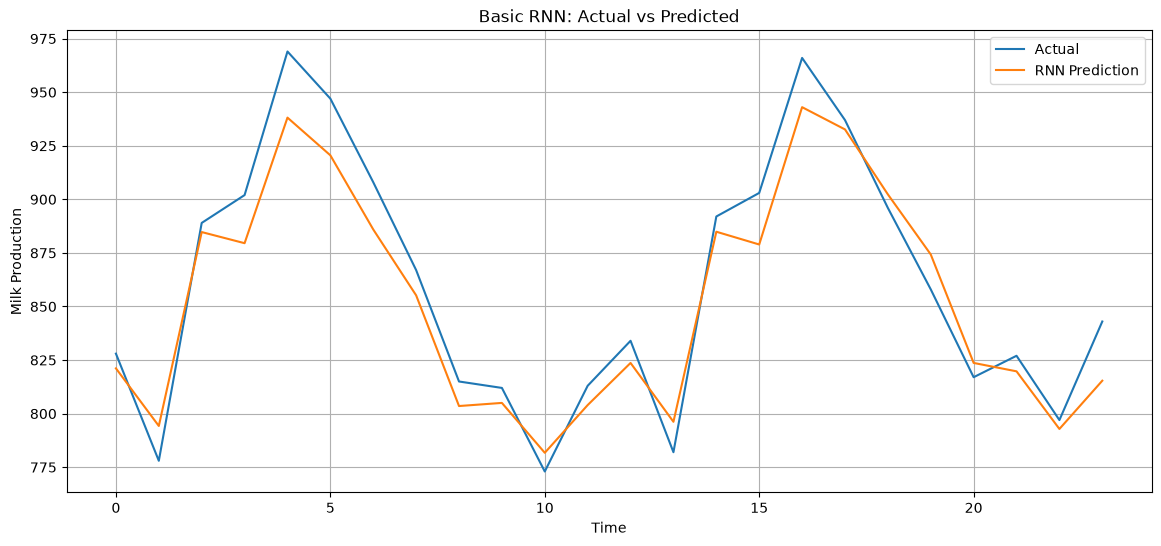

In [50]:
plt.figure(figsize=(14,6))

plt.plot(y_test_actual, label='Actual')
plt.plot(rnn_pred, label='RNN Prediction')

plt.title("Basic RNN: Actual vs Predicted")
plt.xlabel("Time")
plt.ylabel("Milk Production")
plt.legend()
plt.grid(True)
plt.show()

Plot Actual vs Predicted (LSTM)

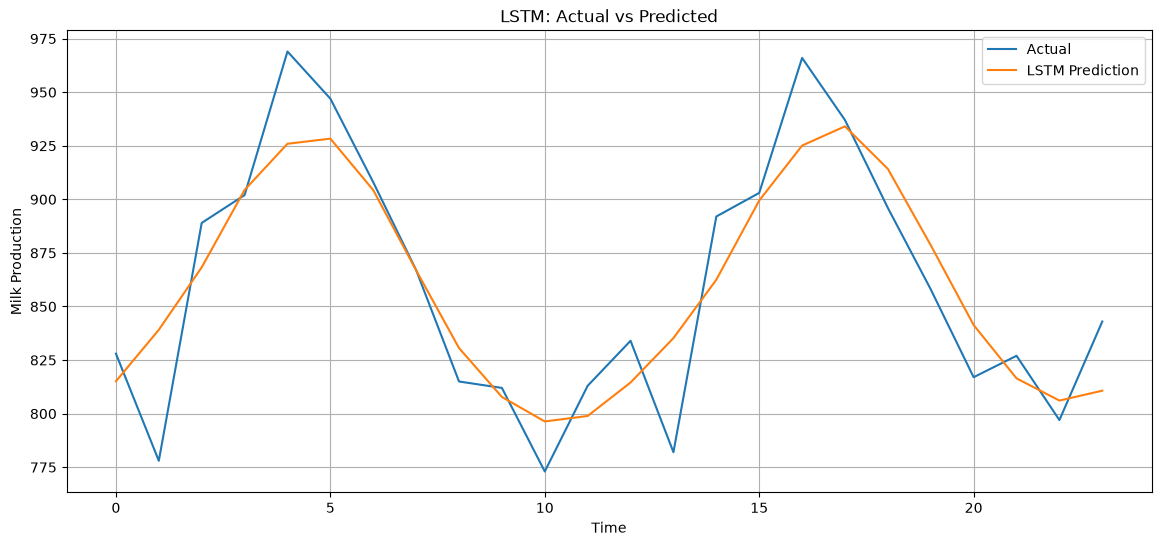

In [51]:
plt.figure(figsize=(14,6))

plt.plot(y_test_actual, label='Actual')
plt.plot(lstm_pred, label='LSTM Prediction')

plt.title("LSTM: Actual vs Predicted")
plt.xlabel("Time")
plt.ylabel("Milk Production")
plt.legend()
plt.grid(True)
plt.show()

Plot Actual vs Predicted (GRU)

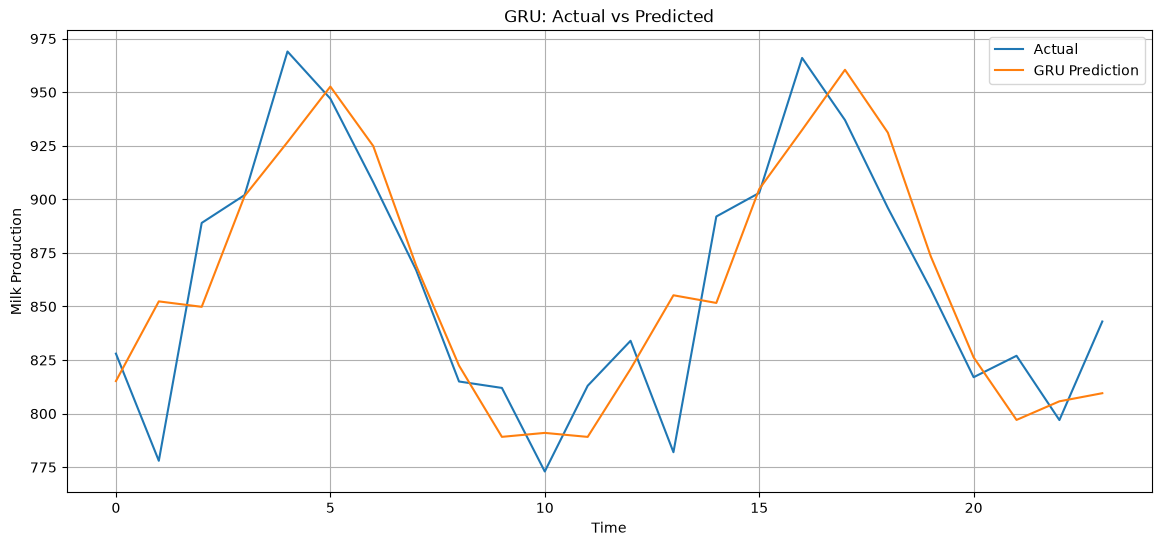

In [52]:
plt.figure(figsize=(14,6))

plt.plot(y_test_actual, label='Actual')
plt.plot(gru_pred, label='GRU Prediction')

plt.title("GRU: Actual vs Predicted")
plt.xlabel("Time")
plt.ylabel("Milk Production")
plt.legend()
plt.grid(True)
plt.show()

In [53]:
print(results.sort_values(by="RMSE"))

       Model       RMSE        MAE  MAPE (%)
0  Basic RNN  15.963947  13.688838  1.567243
1       LSTM  25.758258  20.192169  2.378476
2        GRU  31.164288  24.308385  2.866559


Among the three models, the Basic RNN achieved the best forecasting performance, with the lowest values of RMSE (15.96), MAE (13.69), and MAPE (1.57%). These results indicate that the Basic RNN produced predictions that were closest to the actual monthly milk production values and achieved an average percentage error of only 1.57%, demonstrating excellent forecasting accuracy.

#### Forecast Next 12 Months

In [ ]:
future_steps = 12

last_sequence = scaled_data[-time_step:]

future_predictions = []

current_sequence = last_sequence.copy()

for i in range(future_steps):

    current_input = current_sequence.reshape((1, time_step, 1))

    next_pred = rnn_model.predict(current_input, verbose=0)

    future_predictions.append(next_pred[0,0])

    current_sequence = np.append(current_sequence[1:], next_pred)

future_predictions = scaler.inverse_transform(
    np.array(future_predictions).reshape(-1,1)
)

In [ ]:
future_dates = pd.date_range(
    start=df.index[-1] + pd.DateOffset(months=1),
    periods=12,
    freq='MS'
)

forecast_df = pd.DataFrame({
    "Month":future_dates,
    "Forecasted Milk Production":future_predictions.flatten()
})

forecast_df

,Month,Forecasted Milk Production
0,1976-01-01,832.250610
1,1976-02-01,803.372986
2,1976-03-01,884.728271
3,1976-04-01,881.643433
4,1976-05-01,939.636841
5,1976-06-01,920.497070
6,1976-07-01,893.700317
7,1976-08-01,870.178772
8,1976-09-01,828.188599
9,1976-10-01,836.863708


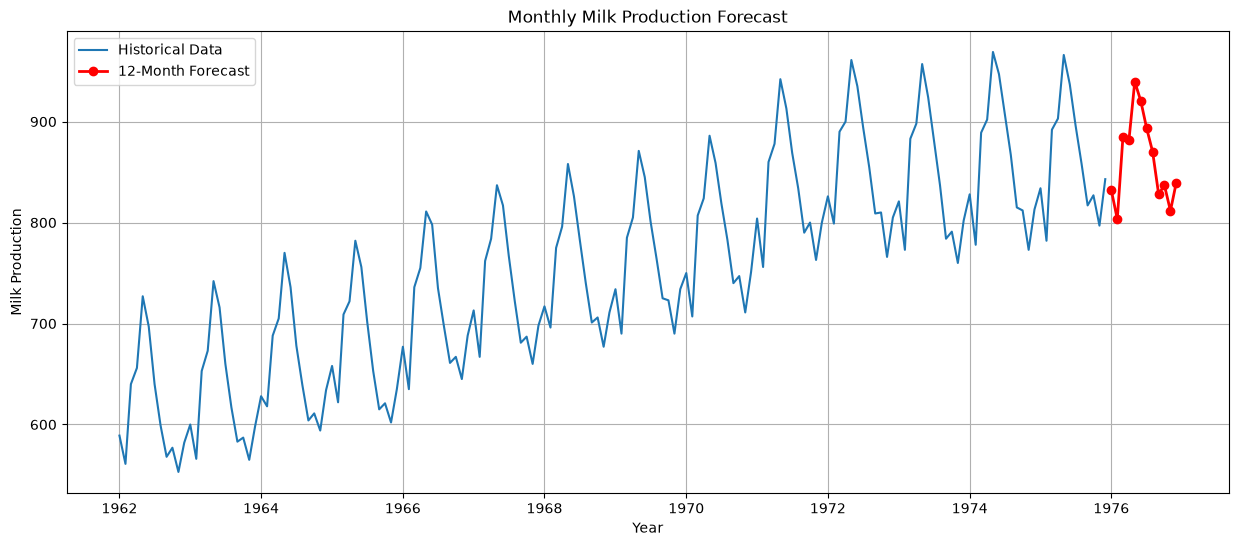

In [57]:
plt.figure(figsize=(15,6))

plt.plot(df.index,
         df['Production'],
         label="Historical Data")

plt.plot(forecast_df["Month"],
         forecast_df["Forecasted Milk Production"],
         color="red",
         marker='o',
         linewidth=2,
         label="12-Month Forecast")

plt.title("Monthly Milk Production Forecast")
plt.xlabel("Year")
plt.ylabel("Milk Production")

plt.legend()
plt.grid(True)

plt.show()

Confidence Interval (Approximation) and Forecast with Confidence Interval

In [58]:
rmse = rnn_rmse

forecast_df["Lower Bound"] = (
    forecast_df["Forecasted Milk Production"] - 1.96*rmse
)

forecast_df["Upper Bound"] = (
    forecast_df["Forecasted Milk Production"] + 1.96*rmse
)

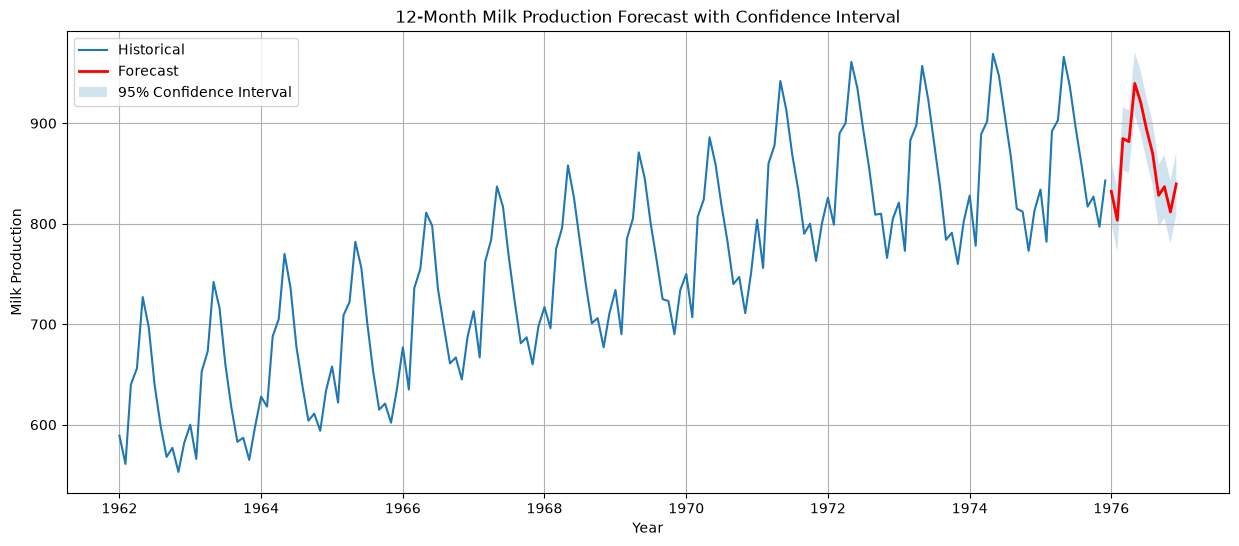

In [60]:
plt.figure(figsize=(15,6))

plt.plot(df.index,
         df["Production"],
         label="Historical")

plt.plot(forecast_df["Month"],
         forecast_df["Forecasted Milk Production"],
         color="red",
         linewidth=2,
         label="Forecast")

plt.fill_between(
    forecast_df["Month"],
    forecast_df["Lower Bound"],
    forecast_df["Upper Bound"],
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.title("12-Month Milk Production Forecast with Confidence Interval")
plt.xlabel("Year")
plt.ylabel("Milk Production")

plt.legend()
plt.grid(True)

plt.show()

In [61]:
forecast_df

,Month,Forecasted Milk Production,Lower Bound,Upper Bound
0,1976-01-01,832.250610,800.961304,863.539917
1,1976-02-01,803.372986,772.083679,834.662292
2,1976-03-01,884.728271,853.438965,916.017578
3,1976-04-01,881.643433,850.354126,912.932739
4,1976-05-01,939.636841,908.347534,970.926147
5,1976-06-01,920.497070,889.207764,951.786377
6,1976-07-01,893.700317,862.411011,924.989624
7,1976-08-01,870.178772,838.889465,901.468079
8,1976-09-01,828.188599,796.899292,859.477905
9,1976-10-01,836.863708,805.574402,868.153015


#### Business Insights

The Basic RNN model achieved the lowest forecasting errors among all evaluated models (RMSE = 15.96, MAE = 13.69, and MAPE = 1.57%), indicating that it can predict monthly milk production with high accuracy. The forecast for the next 12 months follows the historical seasonal pattern, suggesting that milk production is expected to remain relatively stable with predictable seasonal fluctuations.

The confidence interval provides a likely range within which future production values may fall, allowing planners to account for normal forecasting uncertainty.

The developed deep learning forecasting system successfully predicted future monthly milk production using Basic RNN, LSTM, and GRU models. Based on the evaluation metrics, the Basic RNN emerged as the best-performing model, achieving the lowest RMSE (15.96), MAE (13.69), and MAPE (1.57%). This indicates that the simpler recurrent architecture was sufficient to capture the temporal and seasonal patterns present in the dataset. Using the Basic RNN, forecasts for the next 12 months were generated, providing a reliable basis for operational planning. These forecasts can support production scheduling, inventory management, workforce allocation, supply chain coordination, and financial planning, enabling the dairy business to make informed, data-driven decisions while minimizing waste and meeting market demand effectively.